# Lachesis Stop Detection

The first stop detection algorithm implemented in ```nomad``` is a sequential algorithm insipired by the one in _Project Lachesis: Parsing and Modeling Location Histories_ (Hariharan & Toyama). This algorithm for extracting stays is dependent on two parameters: the roaming distance and the stay duration. 

* Roaming distance represents the maximum distance an object can move away from a point location and still be considered to be staying at that location.
* Stop duration is the minimum amount of time an object must spend within the roaming distance of a location to qualify as a stop.

The algorithm identifies stops as contiguous sequences of pings that stay within the roaming distance for at least the duration of the stop duration.

This algorithm has the following parameters, which determine the size of the resulting stops:
* ```dur_min```: Minimum duration for a stay in minutes.
* ```dt_max```: Maximum time gap permitted between consecutive pings in a stay in minutes (dt_max should be greater than dur_min).
* ```delta_roam```: Maximum roaming distance for a stay in meters.

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
<<<<<<< local
=======
import numpy as np
>>>>>>> remote

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
<<<<<<< local
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles
=======
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry
>>>>>>> remote
import nomad.stop_detection.lachesis as LACHESIS
import nomad.stop_detection.dbscan as DBSCAN

import nomad.data as data_folder
from pathlib import Path
<<<<<<< local

=======
>>>>>>> remote
from nomad.city_gen import City
import pandas as pd
import datetime
import json
import matplotlib.dates as mdates
import pandas as pd
import nomad.generation.viz as viz
from nomad.traj_gen import Agent, condense_destinations

In [ ]:
# Parameters according to the config file
<<<<<<< local
data_dir = Path(data_folder.__file__).parent
city = City.from_geopackage(data_dir / "garden-city.gpkg")
buildings = gpd.read_parquet(data_dir / "garden-city-buildings-mercator.parquet")
=======
with open('config_low_ha.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

# users = loader.sample_users(config["output_files"]["diaries_path"], format='parquet', size = 600)
# tc = {"x": "x", "y": "y", "timestamp": "timestamp"}

city = City.from_geopackage(config["city_file"])
>>>>>>> remote

In [3]:
<<<<<<< local
fig, ax = plt.subplots(figsize=(3,3))
=======
fig, ax = plt.subplots(figsize=(12,12))
>>>>>>> remote

city.plot_city(ax=ax)

<<<<<<< local
# Destination Diary for 3 stop trajectory
=======
# Destination Diary
>>>>>>> remote

In [ ]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=6, freq='30min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [30]*6  # in minutes
<<<<<<< local

location = ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 2 + ['r-x20-y13'] * 1
=======
# location = ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 1
location = ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 2 + ['h-x14-y11'] * 1
>>>>>>> remote


destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

<<<<<<< local
destinations = condense_destinations(destinations)
destinations = destinations[:-1]
destinations
=======
destinations = condense_destinations(destinations)
>>>>>>> remote

In [ ]:
<<<<<<< local
Charlie = Agent(identifier="Andres",
=======
Charlie = Agent(identifier="Charlie",
>>>>>>> remote
                city=city)

# Convert datetime column
# destinations['datetime'] = pd.to_datetime(destinations['datetime'])
Charlie.generate_trajectory(destination_diary=destinations,
                            seed=19104,
<<<<<<< local
                            dt=0.2)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=7,
                          seed=60,
                          ha=11/15)

traj = Charlie.sparse_traj
=======
                            dt=0.25)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=4,
                          seed=215,
                          ha=10/15)
>>>>>>> remote

<span style="color:red"><b><<<<<<< local</b></span>

### Plot normal stops

In [6]:
# outer_box = box(*city.city_boundary.bounds)
delta_roam = 2.5
dt_max=120
dur_min=5
stops = LACHESIS.lachesis(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, timestamp='timestamp')
traj['cluster'] = labels

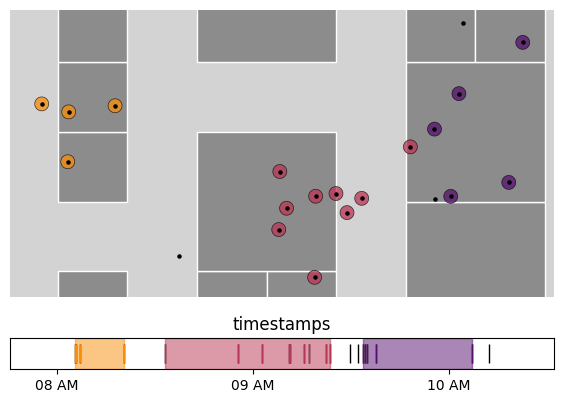

In [7]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,4.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.1, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=5, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('normal_clusters.svg' , format='svg')
plt.savefig('normal_clusters.png' , format='png', dpi=300)
plt.show()

### Ground truth, undersmoothing oversmoothing

In [8]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=6, freq='30min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [30]*6  # in minutes

location = ['p-x12-y11'] * 1 + ['h-x14-y11'] * 1 + ['w-x17-y10'] * 2 + ['r-x19-y11'] * 2

destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)
destinations = condense_destinations(destinations)

Charlie = Agent(identifier="Paco", city=city)

# Convert datetime column
# destinations['datetime'] = pd.to_datetime(destinations['datetime'])
Charlie.generate_trajectory(destination_diary=destinations,
                            seed=1005,
                            dt=0.15)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=5.3,
                          seed=1005,
                          ha=9/15)



In [9]:
dt_max=220
dur_min=5

output = []
## Undersmoothing
delta_roam = 0.8
traj = Charlie.sparse_traj.copy()
stops = LACHESIS.lachesis(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, timestamp='timestamp')
traj['cluster'] = labels
output += [(traj, stops)]
## Normal
delta_roam = 3.9
traj = Charlie.sparse_traj.copy()
stops = LACHESIS.lachesis(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, timestamp='timestamp')
traj['cluster'] = labels
output += [(traj, stops)]
## Oversmoothing
delta_roam = 6
traj = Charlie.sparse_traj.copy()
stops = LACHESIS.lachesis(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(traj, delta_roam=delta_roam, dt_max=dt_max, dur_min=dur_min, timestamp='timestamp')
traj['cluster'] = labels
output += [(traj, stops)]


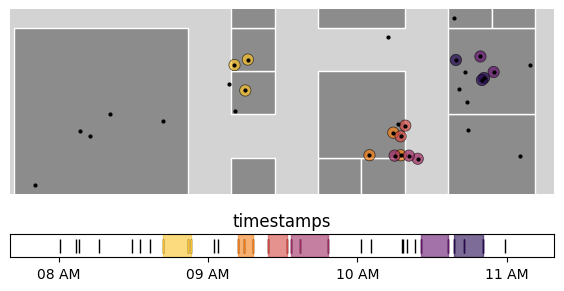

In [10]:
## Undersmoothing 
traj, stops = output[0]
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.13, alpha=0.7, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=4, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('undersmooth_clusters.svg' , format='svg')
plt.savefig('undersmooth_clusters.png' , format='png', dpi=300)
plt.show()

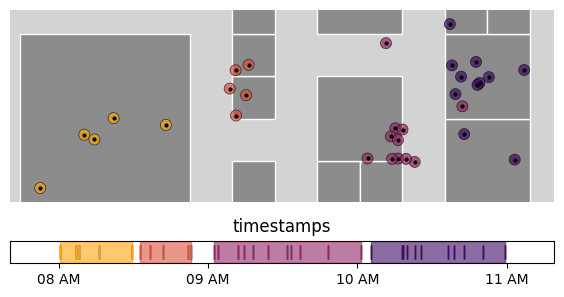

In [11]:
## Normal 
traj, stops = output[1]
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.13, alpha=0.7, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=4, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('good_clusters.svg' , format='svg')
plt.savefig('good_clusters.png' , format='png', dpi=300)
plt.show()

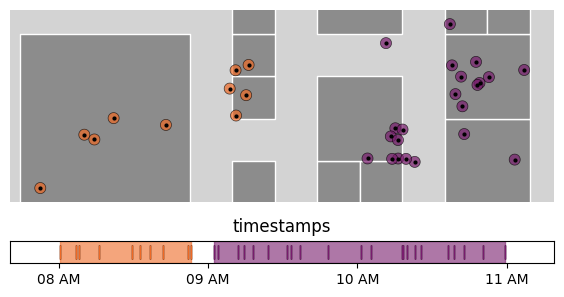

In [12]:
## Oversmoothing 
traj, stops = output[2]
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.13, alpha=0.7, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=4, color='black')

plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('oversmooth_clusters.svg' , format='svg')
plt.savefig('oversmooth_clusters.png' , format='png', dpi=300)
plt.show()

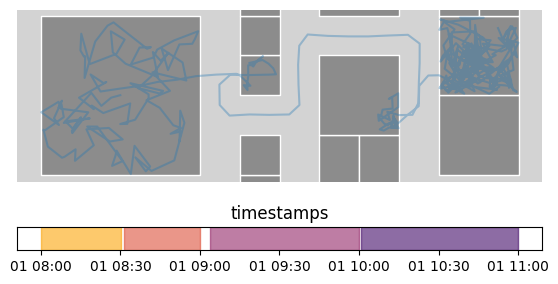

In [13]:
## Ground truth only 
traj = Charlie.trajectory
stops = Charlie.diary.dropna()

fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),
                                         gridspec_kw={'height_ratios':[10,1]})


# Plot colored pings
plot_pings(traj, ax=ax_map, radius=0.13, alpha=0, base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
ax_map.plot(traj.x, traj.y, alpha=0.35)
#ax_map.set_axis_off()
#plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap='inferno_r', set_xlim=False, timestamp='timestamp')

ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig('true_clusters.svg' , format='svg')
plt.savefig('true_clusters.png' , format='png', dpi=300)
plt.show()

<span style="color:red"><b>=======</b></span>

In [ ]:
import numpy as np
from scipy.spatial.distance import pdist

def compute_building_distances(diary_df, poi_table):
    """
    Compute pairwise distances between all buildings visited in the diary.
    
    Parameters:
    -----------
    diary_df : pd.DataFrame
        Diary for a single user with 'location' column
    poi_table : gpd.GeoDataFrame
        POI table with geometry
    
    Returns:
    --------
    np.ndarray : Array of pairwise distances (in meters)
    """
    # Get unique locations (excluding None/NaN)
    unique_locations = diary_df['location'].dropna().unique()
    
    if len(unique_locations) < 2:
        return np.array([])
    
    # Get centroids of these buildings
    poi_subset = poi_table[poi_table['location'].isin(unique_locations)].copy()
    poi_subset['centroid_x'] = poi_subset.geometry.centroid.x
    poi_subset['centroid_y'] = poi_subset.geometry.centroid.y
    
    # Create coordinate matrix
    coords = poi_subset[['centroid_x', 'centroid_y']].values
    
    # Compute pairwise distances
    distances = pdist(coords, metric='euclidean')
    
    return distances


def compute_stop_duration_fractions(diary_df):
    """
    Compute the fraction of each stop relative to total stop duration.
    
    Parameters:
    -----------
    diary_df : pd.DataFrame
        Diary with 'duration' column
    
    Returns:
    --------
    pd.Series : Fraction of total duration for each stop
    """
    # Filter to stops with locations only
    stops_with_locations = diary_df[diary_df['location'].notna()].copy()
    
    total_duration = stops_with_locations['duration'].sum()
    
    if total_duration == 0:
        return pd.Series([])
    
    fractions = stops_with_locations['duration'] / total_duration
    
    return fractions


def analyze_diary_characteristics(diaries_df, poi_table):
    """
    Analyze building distances and stop duration fractions for all users.
    
    Returns:
    --------
    pd.DataFrame : Summary statistics per user
    """
    results = []
    
    for user_id in tqdm(diaries_df['user_id'].unique(), desc='Analyzing diaries'):
        user_diary = diaries_df[diaries_df['user_id'] == user_id].copy()
        
        # 1) Building distances
        distances = compute_building_distances(user_diary, poi_table)
        
        # 2) Stop duration fractions
        fractions = compute_stop_duration_fractions(user_diary)
        
        results.append({
            'user_id': user_id,
            # 'n_unique_locations': user_diary['location'].dropna().nunique(),
            'n_stops': len(user_diary[user_diary['location'].notna()]),
            'mean_building_distance': np.mean(distances) if len(distances) > 0 else np.nan,
            # 'median_building_distance': np.median(distances) if len(distances) > 0 else np.nan,
            # 'max_building_distance': np.max(distances) if len(distances) > 0 else np.nan,
            # 'min_building_distance': np.min(distances) if len(distances) > 0 else np.nan,
            'mean_stop_fraction': fractions.mean() if len(fractions) > 0 else np.nan,
            # 'max_stop_fraction': fractions.max() if len(fractions) > 0 else np.nan,
            # 'std_stop_fraction': fractions.std() if len(fractions) > 0 else np.nan
        })
    
    return pd.DataFrame(results)


# Run analysis
diary_chars_df = analyze_diary_characteristics(diary_one_user, poi_table)

# Display results
print("Diary Characteristics Summary:")
print(diary_chars_df.head(10))
# print("\nOverall Statistics:")
# print(diary_chars_df[['mean_building_distance', 'mean_stop_fraction', 'max_stop_fraction']].describe())

# Save to CSV
# diary_chars_df.to_csv('figures/diary_characteristics.csv', index=False)

# # Visualize
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # 1. Mean building distances
# axes[0].hist(diary_chars_df['mean_building_distance'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
# axes[0].set_xlabel('Mean Distance Between Buildings (meters)', fontsize=13)
# axes[0].set_ylabel('Number of Users', fontsize=13)
# axes[0].set_title('Distribution of Mean Building Distances', fontsize=14, fontweight='bold')
# axes[0].grid(True, alpha=0.3)

# # 2. Max stop fraction
# axes[1].hist(diary_chars_df['max_stop_fraction'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='coral')
# axes[1].set_xlabel('Largest Stop Duration Fraction', fontsize=13)
# axes[1].set_ylabel('Number of Users', fontsize=13)
# axes[1].set_title('Distribution of Max Stop Duration Fraction', fontsize=14, fontweight='bold')
# axes[1].grid(True, alpha=0.3)

# # 3. Mean stop fraction
# axes[2].hist(diary_chars_df['mean_stop_fraction'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
# axes[2].set_xlabel('Mean Stop Duration Fraction', fontsize=13)
# axes[2].set_ylabel('Number of Users', fontsize=13)
# axes[2].set_title('Distribution of Mean Stop Duration Fraction', fontsize=14, fontweight='bold')
# axes[2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('figures/diary_characteristics.png', dpi=300, bbox_inches='tight')
# plt.savefig('figures/diary_characteristics.svg', bbox_inches='tight')
# plt.show()

# print(f"\nResults saved to figures/diary_characteristics.csv")

In [141]:
def plot_time_barcode_colored(ts_series, cluster_labels, ax, cmap='tab20c', 
                               noise_color='black', set_xlim=True):
    """
    Plot a barcode of timestamps colored by their stop cluster.
    
    Parameters
    ----------
    ts_series : pd.Series
        Timestamps (unix seconds).
    cluster_labels : pd.Series
        Cluster labels for each timestamp (-1 for noise/non-stop points).
    ax : matplotlib.axes.Axes
        Axis to draw on.
    cmap : str or Colormap, default 'tab20c'
        Colormap for cluster colors.
    noise_color : color, default 'black'
        Color for noise points (cluster -1).
    set_xlim : bool, default True
        Auto-set x-axis limits with padding.
    
    Returns
    -------
    list
        List of vline collections.
    """
    ts_dt = pd.to_datetime(ts_series, unit='s')
    
    if set_xlim:
        pad = pd.Timedelta(minutes=20)
        ax.set_xlim(ts_dt.min() - pad, ts_dt.max() + pad)
    
    # Get unique clusters (excluding noise)
    unique_clusters = cluster_labels.unique()
    unique_clusters = unique_clusters[unique_clusters >= 0]
    num_clusters = len(unique_clusters)
    
    # Get colormap
    cmap_obj = plt.get_cmap(cmap)
    
    vlines = []
    
    # Plot noise points
    noise_mask = cluster_labels == -1
    if noise_mask.any():
        vlines.append(ax.vlines(ts_dt[noise_mask], 0.2, 0.8, 
                                colors=noise_color, lw=1, alpha=0.5))
    
    # Plot each cluster with its color
    if num_clusters > 0:
        for cid in unique_clusters:
            cluster_mask = cluster_labels == cid
            if cluster_mask.any():
                col = cmap_obj(cid / num_clusters)
                vlines.append(ax.vlines(ts_dt[cluster_mask], 0.2, 0.8, 
                                       colors=col, lw=1, alpha=1, zorder=2))
    
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    
    # Time axis formatting
    time_range = (ts_dt.max() - ts_dt.min()).total_seconds()
    
    if time_range <= 3600 * 12:
        major_locator = mdates.HourLocator(interval=1)
        formatter = mdates.DateFormatter('%I %p')
        minor_locator = None
    elif time_range <= 3600 * 72:
        major_locator = mdates.HourLocator(interval=6)
        formatter = mdates.DateFormatter('%I %p')
        minor_locator = mdates.HourLocator(interval=1)
    else:
        major_locator = mdates.DayLocator()
        formatter = mdates.DateFormatter('%a\n%I %p')
        minor_locator = mdates.HourLocator(interval=6)
    
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(formatter)
    
    if minor_locator is not None:
        ax.xaxis.set_minor_locator(minor_locator)
        ax.tick_params(axis='x', which='minor', length=3)
    
    ax.tick_params(axis='x', which='major', labelsize=10)
    
    return vlines

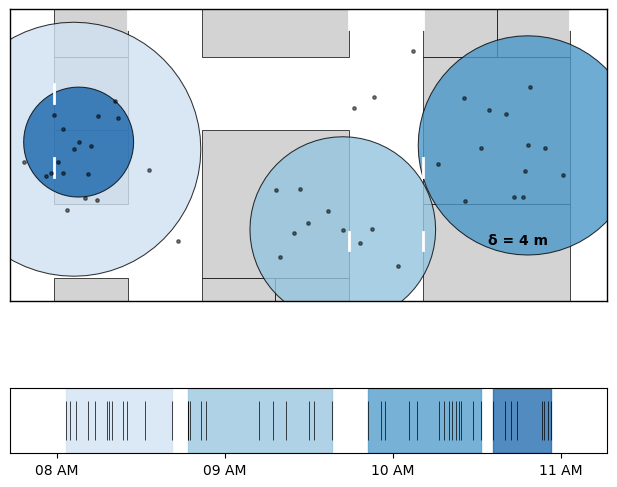

In [142]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# outer_box = box(*city.city_boundary.bounds)
delta_roam = 4
stops = LACHESIS.lachesis(Charlie.sparse_traj, delta_roam=delta_roam, dt_max=40, dur_min=5, 
                         complete_output=True, keep_col_names=True, timestamp='timestamp')
labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=40, delta_roam=delta_roam, dur_min=5)


fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

plot_stops(stops, ax=ax_map, cmap='Blues')
plot_pings(Charlie.sparse_traj, ax=ax_map, s=6, color='black', alpha=0.5)

# Add border instead of turning off axis
ax_map.spines['top'].set_visible(True)
ax_map.spines['right'].set_visible(True)
ax_map.spines['bottom'].set_visible(True)
ax_map.spines['left'].set_visible(True)
ax_map.spines['top'].set_linewidth(1)
ax_map.spines['right'].set_linewidth(1)
ax_map.spines['bottom'].set_linewidth(1)
ax_map.spines['left'].set_linewidth(1)
ax_map.set_xticks([])
ax_map.set_yticks([])

# # Add delta_roam scale indicator (bottom-right corner)
x_range = ax_map.get_xlim()[1] - ax_map.get_xlim()[0]
y_range = ax_map.get_ylim()[1] - ax_map.get_ylim()[0]
scale_x = ax_map.get_xlim()[1] - 0.15 * x_range  # Position from right
scale_y = ax_map.get_ylim()[0] + 0.08 * y_range  # Position from bottom


# # Add label
ax_map.text(scale_x, scale_y + 0.4, f'δ = {delta_roam} m', 
           ha='center', va='bottom', fontsize=10, fontweight='bold', zorder=10)

plot_time_barcode(Charlie.sparse_traj['timestamp'], ax=ax_barcode, set_xlim=True)
plot_stops_barcode(stops, ax=ax_barcode, cmap='Blues', set_xlim=False, timestamp='timestamp')

plt.tight_layout(pad=0.1)
plt.show()

/var/folders/nt/0tc5pmb17xd73rr4g1xb0g_00000gn/T/ipykernel_15849/467186859.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


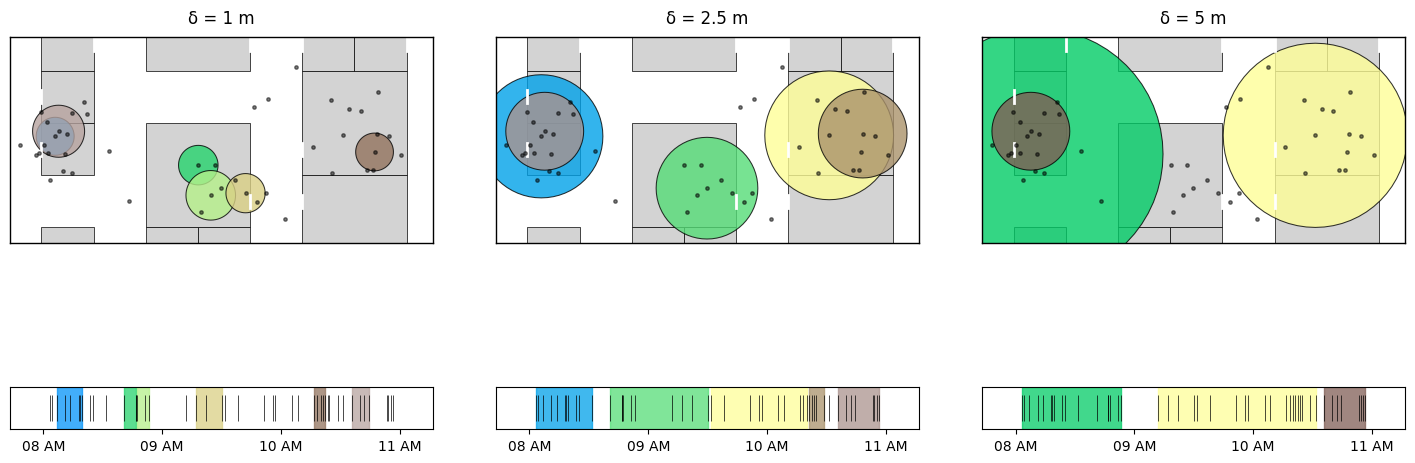

In [143]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Define delta_roam values for comparison
delta_roam_values = [1, 2.5, 5]

fig, axes = plt.subplots(2, 3, figsize=(18, 6.5),
                        gridspec_kw={'height_ratios': [10, 1], 'hspace': 0.15, 'wspace': 0.15})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2

for i, delta_roam in enumerate(delta_roam_values):
    # Run Lachesis with current delta_roam
    stops = LACHESIS.lachesis(Charlie.sparse_traj, 
                             delta_roam=delta_roam, 
                             dt_max=40, 
                             dur_min=5, 
                             complete_output=True, 
                             keep_col_names=True, 
                             timestamp='timestamp')
    
    # Map subplot
    ax_map = axes[0, i]
    ax_map.set_xlim(13.4, 21.5)
    ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
    
    city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)
    plot_stops(stops, ax=ax_map, cmap='terrain')
    plot_pings(Charlie.sparse_traj, ax=ax_map, s=6, color='black', alpha=0.5)
    
    # Add border
    ax_map.spines['top'].set_visible(True)
    ax_map.spines['right'].set_visible(True)
    ax_map.spines['bottom'].set_visible(True)
    ax_map.spines['left'].set_visible(True)
    ax_map.spines['top'].set_linewidth(1)
    ax_map.spines['right'].set_linewidth(1)
    ax_map.spines['bottom'].set_linewidth(1)
    ax_map.spines['left'].set_linewidth(1)
    ax_map.set_xticks([])
    ax_map.set_yticks([])
    
    # Add delta_roam scale indicator
    x_range = ax_map.get_xlim()[1] - ax_map.get_xlim()[0]
    y_range = ax_map.get_ylim()[1] - ax_map.get_ylim()[0]
    scale_x = ax_map.get_xlim()[1] - 0.15 * x_range
    scale_y = ax_map.get_ylim()[0] + 0.08 * y_range
    
    # Add subplot title
    ax_map.set_title(f'δ = {delta_roam} m', fontsize=12, pad=10)
    
    # Barcode subplot
    ax_barcode = axes[1, i]
    plot_time_barcode(Charlie.sparse_traj['timestamp'], ax=ax_barcode, set_xlim=True)
    plot_stops_barcode(stops, ax=ax_barcode, cmap='terrain', set_xlim=False, timestamp='timestamp')

plt.savefig('diff_deltas_clusters.svg', format='svg')
plt.tight_layout(pad=0.1)
plt.show()


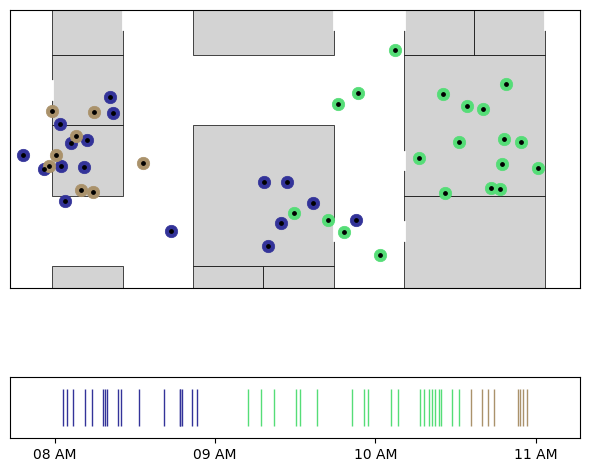

<Figure size 640x480 with 0 Axes>

In [144]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

labels = LACHESIS.lachesis_labels(
    data=Charlie.sparse_traj,
    dt_max=30,
    delta_roam=5,
    dur_min=5)


city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

# ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
#            color='red', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_clusters.svg', format='svg')

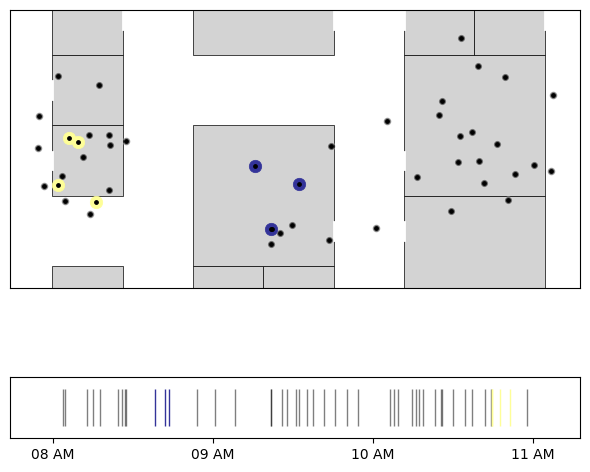

In [222]:
import nomad.filters as filters 
import nomad.stop_detection.grid_based as GRID_BASED

fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}


# normal
# labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=30, delta_roam=3, dur_min=5)

# many visits one point
# labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=30, delta_roam=2, dur_min=5)

# temporal overlap DBSCAN
# labels = DBSCAN.ta_dbscan_labels(Charlie.sparse_traj, time_thresh=180, dist_thresh=1, min_pts=3)

# splitting
# labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=30, delta_roam=1, dur_min=5)

# missingness
labels = LACHESIS.lachesis_labels(data=Charlie.sparse_traj, dt_max=4, delta_roam=1, dur_min=5)


city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

# ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
#            color='red', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.savefig('missing_clusters.svg', format='svg')
plt.show()

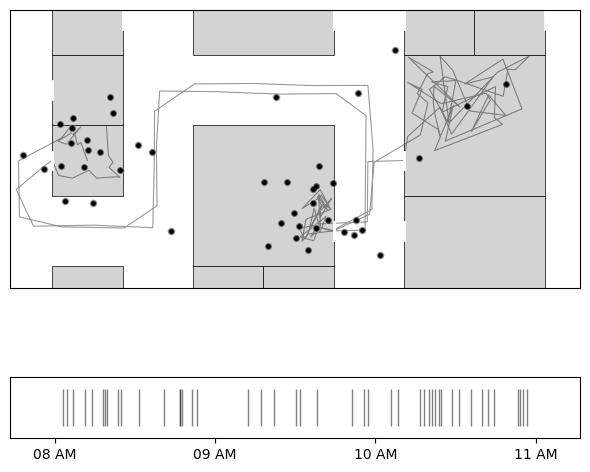

<Figure size 640x480 with 0 Axes>

In [111]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

# colors = {
#                 'street': 'white',
#                 'home': 'skyblue',
#                 'workplace': '#C9A0DC',
#                 'retail': 'lightgrey',
#                 'park': 'lightgreen',
#                 'default': 'lightcoral'
#             }

# labels = LACHESIS.lachesis_labels(
#     data=Charlie.sparse_traj,
#     dt_max=15,
#     delta_roam=2.8,
#     dur_min=5,
#     traj_cols=tc)

labels = LACHESIS.lachesis_labels(
    data=Charlie.sparse_traj,
    dt_max=1,
    delta_roam=1,
    dur_min=5)

# labels = DBSCAN.ta_dbscan(
#     data=Charlie.sparse_traj,
#     time_thresh=600,
#     dist_thresh=0.8,
#     min_pts=3,
#     dur_min=5,
#     traj_cols=tc)

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
           color='black', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('terrain')
unique_clusters = labels.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], 
                          s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], 
              s=6, color='black', alpha=1, zorder=4)

# ax_map.set_title('Lachesis Stop Detection', fontsize=14, pad=10, fontweight='bold')

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels, ax=ax_barcode, 
                          cmap='terrain', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_traj_only.svg', format='svg')

## Figure 3
Examples of the other failures: temporal overlaps, and many visits to one point problem (without overlaps), missingness

/var/folders/nt/0tc5pmb17xd73rr4g1xb0g_00000gn/T/ipykernel_15849/1348020903.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1)


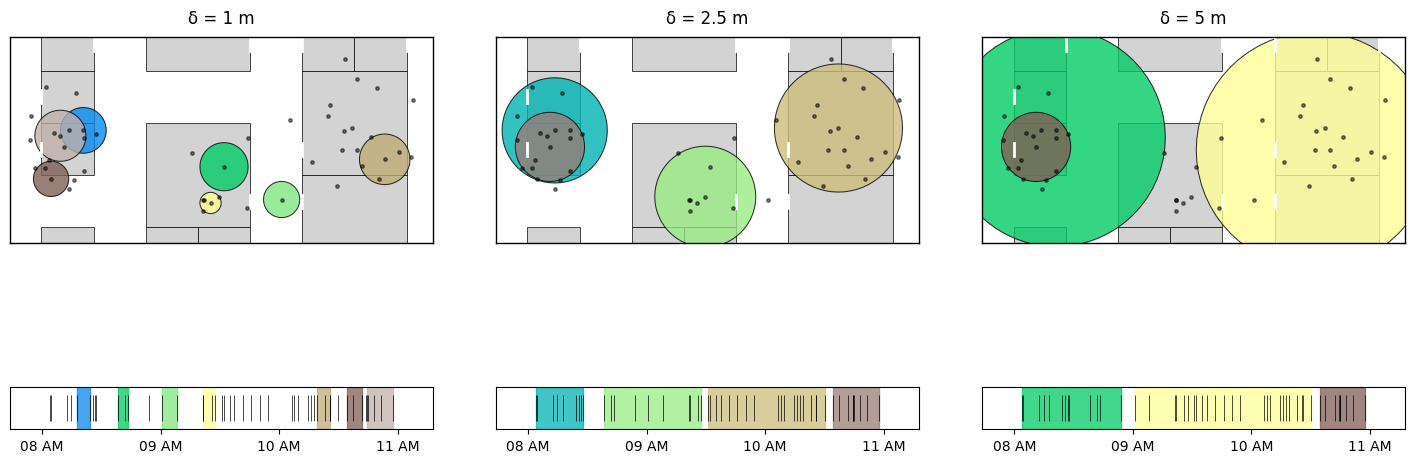

In [153]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Define delta_roam values for comparison
delta_roam_values = [3, 2.5, 5]

fig, axes = plt.subplots(2, 3, figsize=(18, 6.5),
                        gridspec_kw={'height_ratios': [10, 1], 'hspace': 0.15, 'wspace': 0.15})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2

for i, delta_roam in enumerate(delta_roam_values):
    # Run Lachesis with current delta_roam
    stops = LACHESIS.lachesis(Charlie.sparse_traj, 
                             delta_roam=delta_roam, 
                             dt_max=40, 
                             dur_min=5, 
                             complete_output=True, 
                             keep_col_names=True, 
                             timestamp='timestamp')
    
    # Map subplot
    ax_map = axes[0, i]
    ax_map.set_xlim(13.4, 21.5)
    ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
    
    city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)
    plot_stops(stops, ax=ax_map, cmap='terrain')
    plot_pings(Charlie.sparse_traj, ax=ax_map, s=6, color='black', alpha=0.5)
    
    # Add border
    ax_map.spines['top'].set_visible(True)
    ax_map.spines['right'].set_visible(True)
    ax_map.spines['bottom'].set_visible(True)
    ax_map.spines['left'].set_visible(True)
    ax_map.spines['top'].set_linewidth(1)
    ax_map.spines['right'].set_linewidth(1)
    ax_map.spines['bottom'].set_linewidth(1)
    ax_map.spines['left'].set_linewidth(1)
    ax_map.set_xticks([])
    ax_map.set_yticks([])
    
    # Add delta_roam scale indicator
    x_range = ax_map.get_xlim()[1] - ax_map.get_xlim()[0]
    y_range = ax_map.get_ylim()[1] - ax_map.get_ylim()[0]
    scale_x = ax_map.get_xlim()[1] - 0.15 * x_range
    scale_y = ax_map.get_ylim()[0] + 0.08 * y_range
    
    # Add subplot title
    ax_map.set_title(f'δ = {delta_roam} m', fontsize=12, pad=10)
    
    # Barcode subplot
    ax_barcode = axes[1, i]
    plot_time_barcode(Charlie.sparse_traj['timestamp'], ax=ax_barcode, set_xlim=True)
    plot_stops_barcode(stops, ax=ax_barcode, cmap='terrain', set_xlim=False, timestamp='timestamp')

plt.savefig('diff_deltas_clusters.svg', format='svg')
plt.tight_layout(pad=0.1)
plt.show()

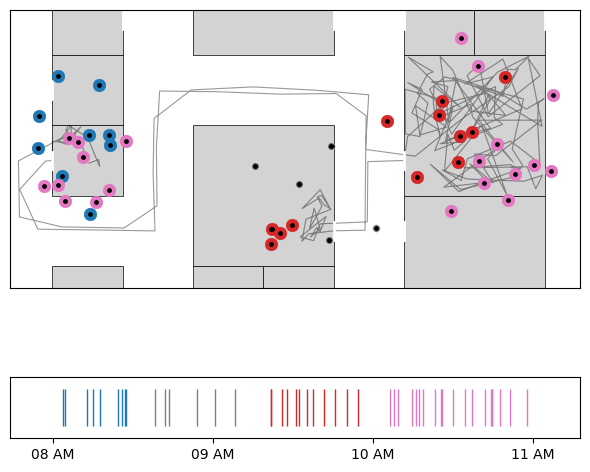

<Figure size 640x480 with 0 Axes>

In [154]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,6.5),
                                         gridspec_kw={'height_ratios':[10,1]})

colors = {
    'home': 'lightgrey',
    'work': 'lightgrey', 
    'retail': 'lightgrey', 
    'park': 'lightgrey',
    'street': 'white',
    'default': 'lightgrey'
}

labels_tadb = DBSCAN.ta_dbscan_labels(Charlie.sparse_traj, time_thresh=10, dist_thresh=10, min_pts=3) 

city.plot_city(ax_map, doors=True, address=False, zorder=0, colors=colors)

ax_map.plot(Charlie.trajectory['x'], Charlie.trajectory['y'], 
           color='black', linewidth=0.8, alpha=0.4, zorder=1)

x0, x1 = Charlie.trajectory.x.min(), Charlie.trajectory.x.max()
y0, y1 = Charlie.trajectory.y.min(), Charlie.trajectory.y.max()
pad_x = (x1 - x0) * 0.5 / 2
pad_y = (y1 - y0) * 0.5 / 2
ax_map.set_xlim(13.4, 21.5)
ax_map.set_ylim(y0 - pad_y, y1 + pad_y)
ax_map.set_xticks([])
ax_map.set_yticks([])
# ax_map.set_title('A) Correct', fontsize=14, pad=10, fontweight='bold')

# Manually plot colored points by cluster to match barcode
cmap_obj = plt.get_cmap('tab10')
unique_clusters = labels_tadb.unique()
unique_clusters = unique_clusters[unique_clusters >= 0]
num_clusters = len(unique_clusters)

# Plot noise points (black)
noise_mask = labels_tadb == -1
if noise_mask.any():
    noise_data = Charlie.sparse_traj[noise_mask]
    ax_map.scatter(noise_data['x'], noise_data['y'], 
                  s=30, color='black', alpha=0.5, zorder=2, edgecolor='white', linewidth=0.5)

# Plot each cluster with matching colors
if num_clusters > 0:
    for cid in unique_clusters:
        cluster_mask = labels_tadb == cid
        if cluster_mask.any():
            cluster_data = Charlie.sparse_traj[cluster_mask]
            col = cmap_obj(cid / num_clusters)
            ax_map.scatter(cluster_data['x'], cluster_data['y'], s=80, color=col, alpha=1, zorder=3, linewidth=0.5)

# Add small black dots on top for all points
ax_map.scatter(Charlie.sparse_traj['x'], Charlie.sparse_traj['y'], s=6, color='black', alpha=1, zorder=4)
# ax_map.scatter(Charlie.sparse_traj.loc[[1717233128,1717233423, 1717233720, 1717234213, 1717234307, 1717234686],'x'], Charlie.sparse_traj.loc[[1717233128,1717233423, 1717233720, 1717234213, 1717234307, 1717234686],'y'], s=6, color='black', alpha=1, zorder=4)

# Barcode with same colormap
plot_time_barcode_colored(Charlie.sparse_traj['timestamp'], labels_tadb, ax=ax_barcode, 
                          cmap='tab10', set_xlim=True)

plt.tight_layout()
plt.show()
plt.savefig('figure1_traj_only.svg', format='svg')

## Figure 4
Show the relevant density for DBSCAN. 3 panels: true, true + noise, true + noise + eps_kernel <<< highlight the saddle point

In [ ]:
# Generate 20 delta_roam values between 5 and 80
delta_roam_values = np.linspace(5, 80, 2)

config["algos"] = {
    **{f"lachesis_delta_{int(dr)}": {
        "func": LACHESIS.lachesis,
        "params": {
            'dt_max': 240,
            'delta_roam': dr
        }
    } for dr in delta_roam_values}
}

results_list = []
for user in tqdm(diaries_df.user_id.unique(), desc='Processing users'):
    sparse = sparse_df.query("user_id==@user").copy()
    truth = diaries_df.query("user_id==@user").copy()
    
    # Run all Lachesis variations
    for algo_name, algo_config in config["algos"].items():
        # Run stop detection
        stops = algo_config["func"](sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        
        # Map stops to buildings
        stops["location"] = visits.point_in_polygon(
            stops, 
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=10, 
            location_id='location', 
            x='x', 
            y='y'
        )
        
        # Compute metrics
        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo_name,
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
        
        # Add delta_roam value to metrics
        metrics['delta_roam'] = algo_config['params']['delta_roam']
        
        results_list.append(metrics)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"Computed metrics for {len(results_df)} user-algorithm combinations")
print(results_df.head())

# Plotting function adapted for delta_roam
def plot_metric_delta_roam(metric, title, save_path='figures'):
    """Plot a metric vs delta_roam for Lachesis."""
    chart_df = results_df.groupby(['delta_roam'])[metric].agg(['mean', 'sem']).reset_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Add scatter plot background (individual data points)
    sns.scatterplot(data=results_df, x='delta_roam', y=metric,
                   alpha=0.2, s=30, ax=ax, color='steelblue')
    
    # Add line plot (mean values)
    ax.plot(chart_df['delta_roam'], chart_df['mean'], 
            color='darkblue', linewidth=3, label='Mean')
    
    # Add confidence band (mean ± SEM)
    ax.fill_between(chart_df['delta_roam'], 
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.3, color='steelblue', label='±1 SEM')
    
    # Styling
    ax.set_xlabel('Delta Roam (meters)', fontsize=15, labelpad=10)
    ax.set_ylabel(title, fontsize=15, labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} vs Delta Roam (Lachesis)', fontsize=16, pad=15, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, linewidth=0.7)
    ax.tick_params(axis='both', which='major', labelsize=13, length=6, width=1.2)
    ax.minorticks_on()
    ax.legend(fontsize=12, frameon=True, loc='best')
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/lachesis_delta_roam_{metric}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}/lachesis_delta_roam_{metric}.png", dpi=600, bbox_inches='tight')
    plt.show(block=False)
    plt.close()

# Plot all metrics
os.makedirs('figures', exist_ok=True)

metrics = {
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1 Score',
    'missed_fraction': 'Proportion of Stops Missed',
    'merged_fraction': 'Proportion of Stops Merged',
    'split_fraction': 'Proportion of Stops Split'
}

for metric, title in metrics.items():
    plot_metric_delta_roam(metric, title)

# Grid plot with all metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, (metric, title) in enumerate(metrics.items()):
    ax = axes.flat[i]
    chart_df = results_df.groupby(['delta_roam'])[metric].agg(['mean', 'sem']).reset_index()
    
    sns.scatterplot(data=results_df, x='delta_roam', y=metric,
                   alpha=0.15, s=20, ax=ax, color='steelblue')
    ax.plot(chart_df['delta_roam'], chart_df['mean'], 
            color='darkblue', linewidth=2.5)
    ax.fill_between(chart_df['delta_roam'], 
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.25, color='steelblue')
    
    ax.set_xlabel('Delta Roam (meters)', fontsize=13, labelpad=8)
    ax.set_ylabel(title, fontsize=13, labelpad=8)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.5, linewidth=0.7)
    ax.tick_params(axis='both', labelsize=11)

plt.tight_layout(pad=2.0, h_pad=2.0, w_pad=2.0)
plt.savefig("figures/lachesis_delta_roam_all_metrics_grid.svg", bbox_inches='tight')
plt.savefig("figures/lachesis_delta_roam_all_metrics_grid.png", dpi=600, bbox_inches='tight')
plt.show(block=False)
plt.close()

print(f"\nDelta roam values tested: {sorted(results_df['delta_roam'].unique())}")
print(f"Number of unique delta_roam values: {results_df['delta_roam'].nunique()}")

<span style="color:red"><b>>>>>>>> remote</b></span>